In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv(r'C:\Users\hp\OneDrive\Desktop\startup_dashboard\startup_funding.csv')
df

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN
...,...,...,...,...,...,...,...,...,...,...
3039,3040,29/01/2015,Printvenue,NaN,NaN,NaN,Asia Pacific Internet Group,Private Equity,"45,00,000",NaN
3040,3041,29/01/2015,Graphene,NaN,NaN,NaN,KARSEMVEN Fund,Private Equity,"8,25,000",Govt backed VC Fund
3041,3042,30/01/2015,Mad Street Den,NaN,NaN,NaN,"Exfinity Fund, GrowX Ventures.",Private Equity,"15,00,000",NaN
3042,3043,30/01/2015,Simplotel,NaN,NaN,NaN,MakeMyTrip,Private Equity,NaN,"Strategic Funding, Minority stake"


### preprocessing
- drop remarks col
- set index sno
- rename col
- convert amount to cr
- date col
- dropna

In [3]:
df.drop(columns=['Remarks'],inplace=True)

In [4]:
df.set_index('Sr No', inplace=True)

In [5]:
df.rename(columns={
    'Date dd/mm/yyyy':'date',
    'Startup Name': 'startup',
    'Industry Vertical': 'vertical',
    'SubVertical':'subvertical',
    'City  Location':'city',
    'Investors Name':'investor',
    'InvestmentnType':'round',
    'Amount in USD':'amount'
},inplace=True)

In [6]:
df

,date,startup,vertical,subvertical,city,investor,round,amount
Sr No,,,,,,,,
1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000"
2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394"
3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860"
4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000"
5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000"
...,...,...,...,...,...,...,...,...
3040,29/01/2015,Printvenue,NaN,NaN,NaN,Asia Pacific Internet Group,Private Equity,"45,00,000"
3041,29/01/2015,Graphene,NaN,NaN,NaN,KARSEMVEN Fund,Private Equity,"8,25,000"
3042,30/01/2015,Mad Street Den,NaN,NaN,NaN,"Exfinity Fund, GrowX Ventures.",Private Equity,"15,00,000"


In [7]:
df['amount'].fillna('0')


Sr No
1       20,00,00,000
2          80,48,394
3        1,83,58,860
4          30,00,000
5          18,00,000
            ...     
3040       45,00,000
3041        8,25,000
3042       15,00,000
3043               0
3044        1,40,000
Name: amount, Length: 3044, dtype: str

In [8]:
df['amount']=df['amount'].str.replace(',','')
df['amount']=df['amount'].str.strip().replace('NaN','0')
df['amount']=df['amount'].str.strip().replace('undisclosed','0')
df['amount']=df['amount'].str.strip().replace('unknown','0')
df['amount']=df['amount'].str.strip().replace('Undisclosed','0')

In [9]:
df['amount']=df['amount'].fillna('0')

In [10]:
df=df[df['amount'].str.isdigit()]
df['amount']=df['amount'].astype(float)

In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 3029 entries, 1 to 3044
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3029 non-null   str    
 1   startup      3029 non-null   str    
 2   vertical     2858 non-null   str    
 3   subvertical  2104 non-null   str    
 4   city         2849 non-null   str    
 5   investor     3005 non-null   str    
 6   round        3027 non-null   str    
 7   amount       3029 non-null   float64
dtypes: float64(1), str(7)
memory usage: 543.1 KB


In [12]:
def usd_inr(dollar):
    return (dollar*95.25)/1e8



In [13]:
df['amount']=df['amount'].apply(usd_inr)

In [14]:
df.sample(5)

,date,startup,vertical,subvertical,city,investor,round,amount
Sr No,,,,,,,,
1605,14/06/2016,Jivox,Technology,Data Driven Advertising platform,Bangalore,"You & Mr Jones, Fortisure Ventures, Diaz Nesam...",Private Equity,5.715000
452,13/12/2017,Capita World,Technology,Artificial Intelligence Platform to Raise Funds,Mumbai,"Mohan Tanksale, Kiran Shetty, Darshak Shah, Ma...",Private Equity,0.000000
1169,21/12/2016,Vegetall,eCommerce,Online Vegetable eTailer,Chennai,The Chennai Angels,Seed Funding,0.154305
244,18/06/2018,Elucidata,IT,Data Analytics (SaaS),Delhi & Cambridge,Hyperplane Venture Capital and several angel i...,Seed/ Angel Funding,1.619250
1586,08/06/2016,Wired Hub,Real Estate,Co-Working Spaces,Jaipur,"Ankit Maheshwari, Anand Singh",Seed Funding,0.000000


In [15]:
# df['date']=pd.to_datetime(df['date'],format="%d/%m/%Y")
# df['date'] = pd.to_datetime(df['date'], dayfirst=True)
# df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=True)

# df['date']=pd.to_datetime(df['date'],errors='coerce')

In [16]:
# failed_dates = df[pd.to_datetime(df['date'], errors='coerce').isna()]['date'].unique()
# print(failed_dates[:20])

In [17]:
# 1. Cast column to string and strip whitespace
df['date'] = df['date'].astype(str).str.strip()

# 2. Fix the common dot typo (e.g., 12/05.2015 -> 12/05/2015)
df['date'] = df['date'].str.replace('.', '/', regex=False)

# 3. Fix double slashes (e.g., 22/01//2015 -> 22/01/2015)
df['date'] = df['date'].str.replace('//', '/', regex=False)

# 4. Correct known extreme anomalies found in this specific Kaggle dataset
df['date'] = df['date'].str.replace('05/072018', '05/07/2018', regex=False)
df['date'] = df['date'].str.replace('01/07/015', '01/07/2015', regex=False)
df['date'] = df['date'].str.replace(r'[^0-9/]', '', regex=True) # strip any remaining hidden characters

# 5. Safely convert to datetime using the 'mixed' format parser
df['date'] = pd.to_datetime(df['date'], format='mixed', errors='coerce')

In [18]:
df.info()

<class 'pandas.DataFrame'>
Index: 3029 entries, 1 to 3044
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         3029 non-null   datetime64[us]
 1   startup      3029 non-null   str           
 2   vertical     2858 non-null   str           
 3   subvertical  2104 non-null   str           
 4   city         2849 non-null   str           
 5   investor     3005 non-null   str           
 6   round        3027 non-null   str           
 7   amount       3029 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(6)
memory usage: 513.1 KB


In [19]:
df['date'].dt.year

Sr No
1       2020
2       2020
3       2020
4       2020
5       2020
        ... 
3040    2015
3041    2015
3042    2015
3043    2015
3044    2015
Name: date, Length: 3029, dtype: int32

In [20]:
df.info()

<class 'pandas.DataFrame'>
Index: 3029 entries, 1 to 3044
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         3029 non-null   datetime64[us]
 1   startup      3029 non-null   str           
 2   vertical     2858 non-null   str           
 3   subvertical  2104 non-null   str           
 4   city         2849 non-null   str           
 5   investor     3005 non-null   str           
 6   round        3027 non-null   str           
 7   amount       3029 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(6)
memory usage: 513.1 KB


In [21]:
df.dropna(subset=['date','startup','vertical','city','investor','round','amount'],inplace=True)

In [22]:
df.info()

<class 'pandas.DataFrame'>
Index: 2823 entries, 1 to 2873
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         2823 non-null   datetime64[us]
 1   startup      2823 non-null   str           
 2   vertical     2823 non-null   str           
 3   subvertical  2078 non-null   str           
 4   city         2823 non-null   str           
 5   investor     2823 non-null   str           
 6   round        2823 non-null   str           
 7   amount       2823 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(6)
memory usage: 486.3 KB


In [23]:
# iname=list(set(df['investor'].str.split(', ').sum()))

In [24]:
# df.to_csv('startup_funding_cleaned.csv', index=False)

In [25]:
# df[df['investor']=='50K Ventures'].head()[['date','startup','vertical','city','round','amount']]
# df[df['investor'].str.contains(selected_investor)]

In [26]:
df[df['investor'].str.contains('50K Ventures')].groupby('startup')['amount'].sum().head(5)

startup
Absentia     0.17145
Commut       0.19050
KhanaGadi    0.00000
i-lend       0.00000
Name: amount, dtype: float64

In [27]:
df['amount']=df['amount'].round()

<Axes: >

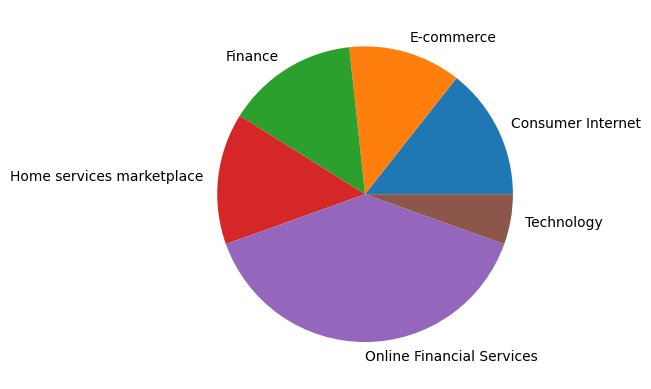

In [28]:
# sector pie chart
df[df['investor'].str.contains('Amazon')].groupby('vertical')['amount'].sum().plot(kind='pie')

In [29]:
df.info()

<class 'pandas.DataFrame'>
Index: 2823 entries, 1 to 2873
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         2823 non-null   datetime64[us]
 1   startup      2823 non-null   str           
 2   vertical     2823 non-null   str           
 3   subvertical  2078 non-null   str           
 4   city         2823 non-null   str           
 5   investor     2823 non-null   str           
 6   round        2823 non-null   str           
 7   amount       2823 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(6)
memory usage: 486.3 KB


In [30]:
# generally invests in
sorted_df=df[df['investor'].str.contains('Amazon')].groupby('vertical')['amount'].sum().sort_values(ascending=False)
top=sorted_df.values[0]
sorted_df[sorted_df>=(0.9*top)]
# df[df['investor'].str.contains('Amazon')].groupby('vertical')['amount'].sum().reset_index(drop=True).sort_values(ascending=False)>=(0.9*top)


vertical
Online Financial Services    57.0
Name: amount, dtype: float64

In [31]:
# round-> pie chart
rounds=df[df['investor'].str.contains('Amazon')].groupby('round')['round'].count()
rounds

round
Private Equity         6
Seed/ Angel Funding    1
Name: round, dtype: int64

In [32]:
# city-> pie chart

In [33]:
# YoY investment graph
# create a column for year

In [34]:
# MoM investment chart(general)
df['month']=df['date'].dt.month
df.groupby(df['month'])['amount'].mean().sort_values(ascending=False).index[0]

np.int32(11)

In [35]:
# max investment in any startup
df.groupby('startup')['amount'].sum().sort_values(ascending=False).head(1).values

array([3868.])

In [36]:
# total funded startups
df['startup'].unique()

<ArrowStringArray>
[                      'BYJU’S',                       'Shuttl',
                    'Mamaearth', 'https://www.wealthbucket.in/',
                       'Fashor',                        'Pando',
                       'Zomato',                       'Ecozen',
                     'CarDekho',                 'Dhruva Space',
 ...
                       'Torqus',                   'LogicRoots',
                        'GIBBS',                     'Babajobs',
                  'Jay Robotix',                  'Naaptol.com',
                      'ReGlobe',                         'Dazo',
                     'Tradelab',                       'PiQube']
Length: 2300, dtype: str

In [37]:
# MoM chart for every year
df['year']=df['date'].dt.year
new_df=df.groupby(['year','month'])['month'].sum()
new_df=new_df.loc[2015]
new_df
# new_df.plot(kind='line')


month
1      36
2      28
3     108
4     260
5     265
6     438
7     588
8     664
9     774
10    760
11    869
12    720
Name: month, dtype: int32

In [38]:
df['startup'].unique()
len(sorted(list(set(df['startup'].str.strip().unique()))))

2300

In [39]:
df

,date,startup,vertical,subvertical,city,investor,round,amount,month,year
Sr No,,,,,,,,,,
1,2020-09-01,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,190.0,9,2020
2,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,8.0,1,2020
3,2020-09-01,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,17.0,9,2020
4,2020-02-01,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,3.0,2,2020
5,2020-02-01,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,2.0,2,2020
...,...,...,...,...,...,...,...,...,...,...
2869,2015-04-29,Tracxn,Startup Analytics platform,NaN,Bangalore,SAIF Partners,Private Equity,3.0,4,2015
2870,2015-04-29,Dazo,Mobile Food Ordering app,NaN,Bangalore,"Sumit Jain, Aprameya Radhakrishna, Alok Goel, ...",Seed Funding,0.0,4,2015
2871,2015-04-29,Tradelab,Financial Markets Software,NaN,Bangalore,Rainmatter,Seed Funding,0.0,4,2015


In [ ]:
df[df['startup'].str.contains('"BYJU\'S"')]['vertical'].values[0]

'E-commerce'

In [44]:
df[df['startup'].str.contains('Mamaearth')]['subvertical'].values[0]

'Retailer of baby and toddler products'

In [54]:
# based city

df[df['startup'].str.contains('"BYJU\'S"')]['city'].isna()

Series([], Name: city, dtype: bool)

In [55]:
# last 5 investments in the start up

df.info()

<class 'pandas.DataFrame'>
Index: 2823 entries, 1 to 2873
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         2823 non-null   datetime64[us]
 1   startup      2823 non-null   str           
 2   vertical     2823 non-null   str           
 3   subvertical  2078 non-null   str           
 4   city         2823 non-null   str           
 5   investor     2823 non-null   str           
 6   round        2823 non-null   str           
 7   amount       2823 non-null   float64       
 8   month        2823 non-null   int32         
 9   year         2823 non-null   int32         
dtypes: datetime64[us](1), float64(1), int32(2), str(6)
memory usage: 508.4 KB


In [67]:
df.sort_values('date',ascending=False).groupby('startup')['amount'].head()

Sr No
7       143.0
1       190.0
3        17.0
4         3.0
5         2.0
        ...  
2668      6.0
2667      0.0
2673      1.0
2753     95.0
2754      0.0
Name: amount, Length: 2813, dtype: float64

In [69]:
df[df['startup'].str.contains('Mamaearth')].sort_values('date',ascending=False).head(5)

,date,startup,vertical,subvertical,city,investor,round,amount,month,year
Sr No,,,,,,,,,,
3,2020-09-01,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,17.0,9,2020
